In [6]:
import faiss
import numpy as np
import pickle

faiss_index = faiss.read_index(
    r"E:\Rohanta_AI_workbook\campus_chatbot\models\clip_faiss\campus_index.faiss"
)
with open(
    r"E:\Rohanta_AI_workbook\campus_chatbot\models\clip_faiss\image_records.pkl", "rb"
) as f:
    image_records = pickle.load(f)

print(f"FAISS index loaded : {faiss_index.ntotal} vectors")
print(f"Image records      : {len(image_records)}")
print(f"Sample record      : {image_records[0]}")

FAISS index loaded : 127 vectors
Image records      : 127
Sample record      : {'path': 'E:\\Rohanta_AI_workbook\\campus_chatbot\\data\\images\\admin_office\\office_01.jpg', 'category': 'admin_office', 'kb_name': 'Admissions & Registry Office'}


In [7]:
import clip
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)
model.eval()

print(f"CLIP loaded on : {device}")
print(f"Model type     : ViT-B/32")

CLIP loaded on : cpu
Model type     : ViT-B/32


In [66]:
from PIL import Image

def search_by_image(image_path: str, top_k: int = 3) -> list:
    # Load and preprocess image
    image = preprocess(Image.open(image_path).convert("RGB")).unsqueeze(0).to(device)
    
    # Get CLIP embedding
    with torch.no_grad():
        embedding = model.encode_image(image)
        embedding = embedding / embedding.norm(dim=-1, keepdim=True)
    
    query = embedding.cpu().numpy().astype("float32")

    # print('embedding')
    # print(len(embedding[0]))
    # print('*'*100)
    
    # Search FAISS
    scores, indices = faiss_index.search(query, top_k)
    # print("indices")
    # print(indices)
    # print('*'*100)
    # print("scores")
    # print(scores)
    # print('*'*100)
    
    results = []
    for score, idx in zip(scores[0], indices[0]):
        record = image_records[idx]
        # print(record)
        results.append({
            "score":    round(float(score), 3),
            "category": record["category"],
            "kb_name":  record["kb_name"],
        })
    return results 


# Test with one image
test_image = r"E:\Rohanta_AI_workbook\campus_chatbot\data\images\library\library_01.jpg"
results = search_by_image(test_image, top_k=3)

print("=== Image Search Test ===\n")
print(results)
for r in results:
    print(f"Score: {r['score']}  Category: {r['category']}  KB: {r['kb_name']}")

=== Image Search Test ===

[{'score': 1.0, 'category': 'library', 'kb_name': 'Main Library'}, {'score': 0.968, 'category': 'library', 'kb_name': 'Main Library'}, {'score': 0.949, 'category': 'library', 'kb_name': 'Main Library'}]
Score: 1.0  Category: library  KB: Main Library
Score: 0.968  Category: library  KB: Main Library
Score: 0.949  Category: library  KB: Main Library


In [10]:
import json

with open(r"E:\Rohanta_AI_workbook\campus_chatbot\data\campus_kb.json", encoding="utf-8") as f:
    kb = json.load(f)

kb_lookup = {entry["name"]: entry for entry in kb}
print(f"KB loaded: {len(kb_lookup)} entries")

def get_kb_info(kb_name: str) -> dict:
    entry = kb_lookup.get(kb_name, {})
    return {
        "name":        entry.get("name", "N/A"),
        "description": entry.get("description", "N/A"),
        "map_ref":     entry.get("map_reference", "N/A"),
        "directions":  entry.get("directions_from_entrance", "N/A"),
        "hours":       entry.get("opening_hours", {}),
        "events":      entry.get("events", []),
    }

# Test
top_match = results[0]["kb_name"]
info      = get_kb_info(top_match)

print(f"\nKB entry for: {top_match}")
print(f"Description : {info['description'][:80]}...")
print(f"Map ref     : {info['map_ref']}")
print(f"Hours Mon   : {info['hours'].get('monday', 'N/A')}")
print(f"Events      : {len(info['events'])} events")

KB loaded: 154 entries

KB entry for: Main Library
Description : A four-floor academic library with over 500 study seats, silent reading zones, g...
Map ref     : Building A, North Campus, Ground to 4th Floor
Hours Mon   : 08:00-22:00
Events      : 3 events


In [31]:
def query_by_image(image_path: str, top_k: int = 3) -> dict:
    # Step 1 — Search FAISS
    results = search_by_image(image_path, top_k=top_k+1)
    
    # Step 2 — Skip self match (score = 1.0)
    results = [r for r in results if r["score"] < 0.999][:top_k]
    
    if not results:
        return {"error": "No match found"}
    
    top = results[0]
    
    # Step 3 — Get KB info
    kb_info = get_kb_info(top["kb_name"])

    print("top")
    print(top)
    print("*"*100)
    print("kb_info")
    print(kb_info)
    print("*"*100)
    
    return {
        "matched_location": top["kb_name"],
        "confidence":       top["score"],
        "category":         top["category"],
        "description":      kb_info["description"],
        "map_ref":          kb_info["map_ref"],
        "directions":       kb_info["directions"],
        "hours":            kb_info["hours"],
        "events":           kb_info["events"],
        "top_matches":      results,
    }


# Test across different categories
test_images = {
    "library":    r"E:\Rohanta_AI_workbook\campus_chatbot\data\images\library\library_02.jpg",
    # "gym":        r"E:\Rohanta_AI_workbook\campus_chatbot\data\images\gym\gym_01.jpg",
    # "cafeteria":  r"E:\Rohanta_AI_workbook\campus_chatbot\data\images\cafeteria\cafeteria_01.jpg",
    # "medical":    r"E:\Rohanta_AI_workbook\campus_chatbot\data\images\medical_center\medical_01.jpg",
}

print("=== Full Image Query Pipeline Test ===\n")
for cat, path in test_images.items():
    result = query_by_image(path)
    print(f"Category  : {cat}")
    print(f"Matched   : {result['matched_location']} ({result['confidence']})")
    print(f"Map ref   : {result['map_ref']}")
    print(f"Top 3     : {result['top_matches']}")
    print("-" * 55)

=== Full Image Query Pipeline Test ===

top
{'score': 0.951, 'category': 'library', 'kb_name': 'Main Library'}
****************************************************************************************************
kb_info
{'name': 'Main Library', 'description': 'A four-floor academic library with over 500 study seats, silent reading zones, group study rooms, and access to digital journals and e-books.', 'map_ref': 'Building A, North Campus, Ground to 4th Floor', 'directions': 'Enter through the Main Gate. Walk straight 100 metres. Building A is the large red-brick building on your left. The library entrance is the glass-fronted door facing north.', 'hours': {'monday': '08:00-22:00', 'tuesday': '08:00-22:00', 'wednesday': '08:00-22:00', 'thursday': '08:00-22:00', 'friday': '08:00-20:00', 'saturday': '09:00-18:00', 'sunday': 'Closed'}, 'events': ['Research Skills Workshop - 28 May 2026, 14:00', 'Academic Writing Seminar - 3 June 2026, 10:00', 'Book Fair - 10 June 2026, 09:00-17:00']}
*****

In [87]:
from langgraph.graph import StateGraph , START , END
from typing import TypedDict, List, Optional, Dict, Any
from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage, HumanMessage
import os
import sys
from pathlib import Path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))
from config.settings import (
    GROQ_API_KEY, GROQ_MODEL,
    LLM_TEMPERATURE, LLM_MAX_TOKENS,
)

In [42]:
llm = ChatGroq(
    model       = GROQ_MODEL,
    temperature = LLM_TEMPERATURE,
    max_tokens  = LLM_MAX_TOKENS,
    api_key     = GROQ_API_KEY,
)

In [73]:
class FAISSMatch(TypedDict):
    score:    float
    category: str
    kb_name:  str

class ImageBotState(TypedDict):

    # ── Input ─────────────────────────────────────
    image_path:  str | None

    # ── After CLIP ────────────────────────────────
    embedding:   list | None

    # ── After FAISS ───────────────────────────────
    top_3_matches:    list[FAISSMatch] | None 
    best_match:       FAISSMatch | None        

    # ── After KB lookup ───────────────────────────
    kb_info: str | None
    name: str | None
    description : str | None
    map_ref: str | None
    directions: str | None
    hours: dict | None
    events : list | None

    # ── After LLM ─────────────────────────────────
    answer:      str | None


In [74]:
def clip_node(state: ImageBotState):
    image_path = state["image_path"]
    image = preprocess(Image.open(image_path).convert("RGB")).unsqueeze(0).to(device)
    
    with torch.no_grad():
        embedding = model.encode_image(image)
        embedding = embedding / embedding.norm(dim=-1, keepdim=True)
    
    state["embedding"] = embedding.cpu().numpy().squeeze().tolist()
    return state
    

In [75]:
def faiss_node(state: ImageBotState) :
    query = np.array(state["embedding"], dtype="float32").reshape(1, -1)
    scores, indices = faiss_index.search(query, 3)

    top_3 = []
    for score, idx in zip(scores[0], indices[0]):
        record = image_records[idx]
        top_3.append({
            "score":    round(float(score), 3),
            "category": record["category"],
            "kb_name":  record["kb_name"],
        })

    # best match — skip self match (score = 1.0)
    non_self  = [r for r in top_3 if r["score"] < 0.999]
    best      = non_self[0] if non_self else top_3[0]

    state["top_3_matches"] = top_3
    state["best_match"]    = best
    return state

In [76]:
def kb_node(state: ImageBotState) :
    best_match = state["best_match"]
    kb_name    = best_match["kb_name"]
    entry      = kb_lookup.get(kb_name, {})

    state["kb_info"]     = kb_name
    state["name"]        = entry.get("name", "N/A")
    state["description"] = entry.get("description", "N/A")
    state["map_ref"]     = entry.get("map_reference", "N/A")
    state["directions"]  = entry.get("directions_from_entrance", "N/A")
    state["hours"]       = entry.get("opening_hours", {})
    state["events"]      = entry.get("events", [])

    return state

In [77]:
def llm_node(state: ImageBotState) :
    prompt = f"""
You are a campus navigation assistant.

The user uploaded an image. It was identified as: {state['name']} 
(confidence: {state['best_match']['score']})

Location   : {state['map_ref']}
Directions : {state['directions']}
Hours      : {state['hours']}
Events     : {state['events']}
Description: {state['description']}

First briefly tell the user what location was found and its key details.
Then ask: "Would you like directions, opening hours, or event information?"
Keep it friendly and concise.
"""

    response = llm.invoke(prompt)
    state["answer"] = response.content.strip()
    return state

In [78]:
graph = StateGraph(ImageBotState)

graph.add_node("clip",  clip_node)
graph.add_node("faiss", faiss_node)
graph.add_node("kb",    kb_node)
graph.add_node("llm",   llm_node)

graph.set_entry_point("clip")
graph.add_edge("clip",  "faiss")
graph.add_edge("faiss", "kb")
graph.add_edge("kb",    "llm")
graph.add_edge("llm",   END)

app = graph.compile()
print("Graph compiled")

Graph compiled


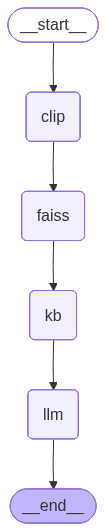

In [79]:
app

In [80]:
app.invoke({'image_path':r'E:\Rohanta_AI_workbook\campus_chatbot\data\images\gym\gym_02.jpg'})["answer"]

"We've identified the location as the Sports & Fitness Centre, located in Building F on the West Campus. Here are the key details:\n\n- Address: Building F, West Campus\n- Directions: Enter through the Main Gate, take the right fork, and follow the western path for 150 metres.\n- Hours: The centre is open from 06:30 to 22:00 on Mondays to Wednesdays and Thursdays, 06:30 to 21:00 on Fridays, 08:00 to 20:00 on Saturdays, and 10:00 to 18:00 on Sundays.\n- Events: There's a Yoga for Beginners session on 28 May 2026 at 07:00 and a Basketball Tournament on 7 June 2026 at 14:00.\n\nWould you like directions, opening hours, or event information?"

In [83]:
import random
from pathlib import Path
image_files = []
IMAGE_DIR = Path(r"E:\Rohanta_AI_workbook\campus_chatbot\data\images")

# Get all images from all categories
all_images = list(IMAGE_DIR.rglob("*.jpg")) + list(IMAGE_DIR.rglob("*.png"))

# Pick 10 random
sample_10 = random.sample(all_images, min(10, len(all_images)))
for i in sample_10:
    image_files.append(i)

# print(f"Total images : {len(all_images)}")
# print(f"\n10 random samples:")
# for img in sample_10:
#     print(f"  {img.relative_to(IMAGE_DIR.parent)}")

In [86]:
for q in image_files:
    try:
        ans = app.invoke({'image_path':str(q)})
        print('*'*50)
        print(q)
        print(ans["answer"])
    except:
        pass

**************************************************
E:\Rohanta_AI_workbook\campus_chatbot\data\images\cafeteria\cafeteria_03.jpg
We've identified the location in the uploaded image as the Main Cafeteria, located in Building B on the Ground Floor of South Campus. Here are some key details:

- Location: Building B, South Campus, Ground Floor
- Description: The primary dining facility on campus offering hot meals, sandwiches, salads, and beverages with vegetarian, vegan, and halal options.
- Seating capacity: 300

Now, would you like directions, opening hours, or event information?
**************************************************
E:\Rohanta_AI_workbook\campus_chatbot\data\images\engineering\engineering_02.jpg
We've identified the location in the image as the Sports & Fitness Centre, located in Building F on the West Campus.

Here are the key details:

- Building Location: Building F, West Campus
- Directions: Enter through the Main Gate, take the right fork, and follow the western path f